### Sentimental analysis

## Step 1 — Data Load

In [ ]:
#Load your processed data
import pandas as pd

df_processed = pd.read_csv(
    "../data/processed/customer_reviews_processed.csv"
)

## Step 2 — Data extraction

In [2]:
#Define input and target

X = df_processed["clean_text"]
y = df_processed["sentiment"]

In [3]:
print("X shape:", X.shape)
print("y shape:", y.shape)
X.head()

X shape: (34614,)
y shape: (34614,)


0    this product so far has not disappointed. my c...
1    great for beginner or experienced person. boug...
2    inexpensive tablet for him to use and learn on...
3    i've had my fire hd 8 two weeks now and i love...
4    i bought this for my grand daughter when she c...
Name: clean_text, dtype: str

In [4]:
y.head()
#X = review text ,y = answer we want the model to learn

0    positive
1    positive
2    positive
3    positive
4    positive
Name: sentiment, dtype: str

## Step 3 — Train/test split

In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [6]:
print("Training:", y_train.value_counts())
print()
print("Test:", y_test.value_counts())

Training: sentiment
positive    25844
neutral      1199
negative      648
Name: count, dtype: int64

Test: sentiment
positive    6461
neutral      300
negative     162
Name: count, dtype: int64


## Step 4 — TF-IDF

In [7]:
from sklearn.feature_extraction.text import TfidfVectorizer
vectorizer = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2)
)

## Step 5 — Fit TF-IDF ONLY on training data

In [8]:
X_train_tfidf = vectorizer.fit_transform(X_train)

In [9]:
X_test_tfidf = vectorizer.transform(X_test)

In [10]:
print("Training shape:", X_train_tfidf.shape)
print("Test shape:", X_test_tfidf.shape)

Training shape: (27691, 10000)
Test shape: (6923, 10000)


## Step 6 :Define Baseline model 

# 1.Logistic Regression

In [11]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

In [12]:
model.fit(
    X_train_tfidf,
    y_train
)

,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default 

In [13]:
y_pred = model.predict(X_test_tfidf)
y_pred[:10]
y_test[:10].values

<ArrowStringArray>
['positive', 'positive', 'positive', 'positive', 'positive', 'positive',
 'positive', 'positive',  'neutral', 'positive']
Length: 10, dtype: str

In [14]:
##Accurancy
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.2%}")

Accuracy: 86.00%


In [15]:
##Step 12 — Precision, Recall and F1
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

    negative       0.33      0.59      0.42       162
     neutral       0.17      0.43      0.24       300
    positive       0.98      0.89      0.93      6461

    accuracy                           0.86      6923
   macro avg       0.49      0.64      0.53      6923
weighted avg       0.93      0.86      0.89      6923



Precision

When the model predicts a class, how often is it correct?
Predicted positive
        ↓
How many were actually positive?


Recall

Of all the actual examples of a class, how many did the model find?

Actual positive
        ↓
How many did the model correctly identify?

F1

Balance between precision and recall.

F1 = balance of precision + recall

In [16]:
from sklearn.metrics import f1_score

macro_f1 = f1_score(
    y_test,
    y_pred,
    average="macro"
)

print(f"Macro F1: {macro_f1:.2%}")

Macro F1: 53.09%


In [17]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    y_pred,
    labels=["negative", "neutral", "positive"]
)

cm

array([[  96,   42,   24],
       [  57,  129,  114],
       [ 142,  590, 5729]])

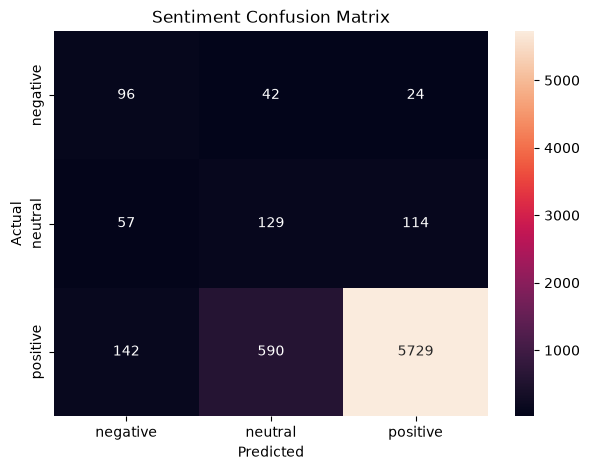

In [18]:
## Visualizing confusion matrix
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["negative", "neutral", "positive"],
    yticklabels=["negative", "neutral", "positive"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Sentiment Confusion Matrix")
plt.show()

## 2.Multinomial Naive Bayes

In [ ]:
#Train Naive Bayes

from sklearn.naive_bayes import MultinomialNB
nb_model = MultinomialNB()

In [20]:
nb_model.fit(
    X_train_tfidf,
    y_train
)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
Name,Type,Value
"class_count_ class_count_: ndarray of shape (n_classes,)Number of samples encountered for each class during fitting. Thisvalue is weighted by the sample weight when provided.","ndarray[float64](3,)","[ 648., 1199.,25844.]"
"class_log_prior_ class_log_prior_: ndarray of shape (n_classes,)Smoothed empirical log probability for each class.","ndarray[float64](3,)","[-3.75,-3.14,-0.07]"
"classes_ classes_: ndarray of shape (n_classes,)Class labels known to the classifier","ndarray[<U8](3,)","['negative','neutral','positive']"
"feature_count_ feature_count_: ndarray of shape (n_classes, n_features)Number of samples encountered for each (class, feature)during fitting. This value is weighted by the sample weight whenprovided.","ndarray[float64](3, 10000)","[[ 0.17, 1.59, 0. ,..., 0. , 0. , 0.19], [ 0.53, 1.78, 0.28,..., 0.2 , 0. , 0. ], [10.55,33.85, 2.4 ,..., 5.21, 3.3 , 2.84]]"
"feature_log_prob_ feature_log_prob_: ndarray of shape (n_classes, n_features)Empirical log probability of featuresgiven a class, ``P(x_i|y)``.","ndarray[float64](3, 10000)","[[ -9.39, -8.6 , -9.55,..., -9.55, -9.55, -9.38], [ -9.31, -8.72, -9.49,..., -9.56, -9.74, -9.74], [ -9.48, -8.37,-10.7 ,...,-10.1 ,-10.46,-10.58]]"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,10000


In [21]:
y_pred_nb = nb_model.predict(X_test_tfidf)

In [22]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred_nb
    )
)

              precision    recall  f1-score   support

    negative       0.00      0.00      0.00       162
     neutral       0.00      0.00      0.00       300
    positive       0.93      1.00      0.97      6461

    accuracy                           0.93      6923
   macro avg       0.31      0.33      0.32      6923
weighted avg       0.87      0.93      0.90      6923



/home/haripriya/anaconda3/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/haripriya/anaconda3/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/haripriya/anaconda3/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.sh

In [23]:
from sklearn.metrics import accuracy_score, f1_score

nb_accuracy = accuracy_score(
    y_test,
    y_pred_nb
)

nb_macro_f1 = f1_score(
    y_test,
    y_pred_nb,
    average="macro"
)

print(f"Naive Bayes Accuracy: {nb_accuracy:.2%}")
print(f"Naive Bayes Macro F1: {nb_macro_f1:.2%}")

Naive Bayes Accuracy: 93.33%
Naive Bayes Macro F1: 32.19%


## 3.Linear SVM

In [ ]:
#Train LinearSVC
from sklearn.svm import LinearSVC
svm_model = LinearSVC(
    class_weight="balanced",
    random_state=42
)
svm_model.fit(
    X_train_tfidf,
    y_train
)
y_pred_svm = svm_model.predict(
    X_test_tfidf
)
print(
    classification_report(
        y_test,
        y_pred_svm
    )
)

              precision    recall  f1-score   support

    negative       0.51      0.38      0.43       162
     neutral       0.29      0.27      0.28       300
    positive       0.96      0.97      0.96      6461

    accuracy                           0.92      6923
   macro avg       0.59      0.54      0.56      6923
weighted avg       0.92      0.92      0.92      6923



In [25]:
svm_accuracy = accuracy_score(
    y_test,
    y_pred_svm
)

svm_macro_f1 = f1_score(
    y_test,
    y_pred_svm,
    average="macro"
)

print(f"SVM Accuracy: {svm_accuracy:.2%}")
print(f"SVM Macro F1: {svm_macro_f1:.2%}")

SVM Accuracy: 92.47%
SVM Macro F1: 56.02%


In [26]:
## confusion matrix of svm model
from sklearn.metrics import confusion_matrix
import pandas as pd

labels = ["negative", "neutral", "positive"]

cm_svm = confusion_matrix(
    y_test,
    y_pred_svm,
    labels=labels
)

cm_svm_df = pd.DataFrame(
    cm_svm,
    index=labels,
    columns=labels
)

cm_svm_df

,negative,neutral,positive
negative,61,33,68
neutral,22,82,196
positive,36,166,6259


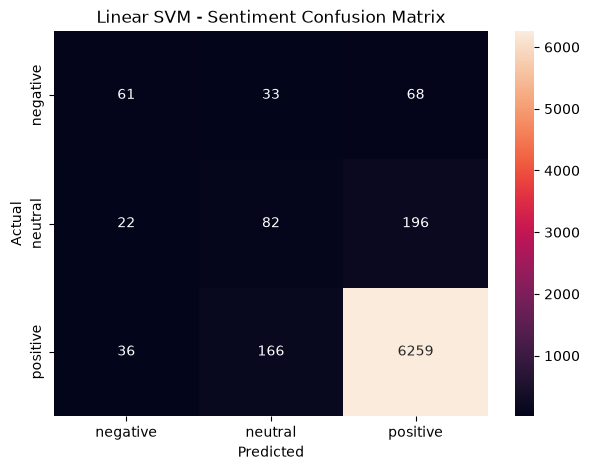

In [ ]:
#Plot Linear SVM Confusion Matrix
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm_svm_df,
    annot=True,
    fmt="d"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Linear SVM - Sentiment Confusion Matrix")

plt.show()

In [ ]:
#Cross-validate 3 TF-IDF classifiers (LogReg, Linear SVM, Calibrated SVM)
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import cross_val_score
from sklearn.calibration import CalibratedClassifierCV

def tfidf():
    return TfidfVectorizer(max_features=10000, ngram_range=(1, 2))

candidates = {
    "Logistic Regression": make_pipeline(
        tfidf(), LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)),
    "Linear SVM": make_pipeline(
        tfidf(), LinearSVC(class_weight="balanced", random_state=42)),
    "Calibrated SVM": make_pipeline(
        tfidf(), CalibratedClassifierCV(LinearSVC(class_weight="balanced", random_state=42), cv=5)),
}

for name, m in candidates.items():
    s = cross_val_score(m, X_train, y_train, cv=5, scoring="f1_macro")
    print(f"{name}: macro F1 {s.mean():.3f} +/- {s.std():.3f}")

Logistic Regression: macro F1 0.538 +/- 0.009
Linear SVM: macro F1 0.551 +/- 0.010
Calibrated SVM: macro F1 0.467 +/- 0.018


## Conclusion

About 93% of the reviews are positive, so accuracy alone is misleading. I compared the
models mainly by macro F1, which counts negative, neutral and positive equally.

| Model | Accuracy | Macro F1 (test) | Negative F1 | Neutral F1 | Positive F1 | Macro F1 (5-fold CV) |
|---|---|---|---|---|---|---|
| Naive Bayes | 93.33% | 32.19% | 0.00 | 0.00 | 0.97 | not run |
| Logistic Regression | 85.95% | 53.97% | 0.44 | 0.25 | 0.93 | 0.534 ± 0.008 |
| Linear SVM | 92.19% | 54.83% | 0.42 | 0.27 | 0.96 | 0.550 ± 0.016 |

**Final model: Logistic Regression.**

- **Naive Bayes:** ruled out. It has the highest accuracy, but it never predicted a negative
  or neutral review, so that accuracy only comes from the positive class.
- **Linear SVM:** best macro F1 and the strongest minority-class scores, but it cannot give a
  confidence score for each class, which the app needs. The gap to Logistic Regression is
  small (about 1.6 points in cross-validation, and the ranges nearly overlap).
- **Logistic Regression:** close to the SVM, gives probabilities directly, and class weights
  help it find the rare classes. Logistic Regression for the deployed demo because it provided comparable overall performance while producing a well-balanced baseline across the sentiment classes.

## Step 7: Select final model

In [33]:
#Train the final pipeline

from sklearn.pipeline import make_pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

pipe = make_pipeline(
    TfidfVectorizer(
        max_features=10000,
        ngram_range=(1, 2)
    ),
    LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    )
)

pipe.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('tfidfvectorizer', ...), ('logisticregression', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[object](3,)","['negative','neutral','positive']"
,"ngram_range ngram_range: tuple (min_n, max_n), default=(1, 1)The lower and upper boundary of the range of n-values for differentn-grams to be extracted. All values of n such that min_n <= n <= max_nwill be used. For example an ``ngram_range`` of ``(1, 1)`` means onlyunigrams, ``(1, 2)`` means unigrams and bigrams, and ``(2, 2)`` meansonly bigrams.Only applies if ``analyzer`` is not callable.","(1, ...)"
,"max_features max_features: int, default=NoneIf not None, build a vocabulary that only consider the top`max_features` ordered by term frequency across the corpus.Otherwise, all features are used.This parameter is ignored if vocabulary is not None.",10000
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'


In [34]:
#Evaluate the final Logistic Regression
from sklearn.metrics import (
    classification_report,
    f1_score,
    accuracy_score,
    confusion_matrix
)

y_pred = pipe.predict(X_test)

print(classification_report(y_test, y_pred))

print(f"Accuracy: {accuracy_score(y_test, y_pred):.2%}")

print(
    f"Macro F1: "
    f"{f1_score(y_test, y_pred, average='macro'):.2%}"
)

              precision    recall  f1-score   support

    negative       0.33      0.59      0.42       162
     neutral       0.17      0.43      0.24       300
    positive       0.98      0.89      0.93      6461

    accuracy                           0.86      6923
   macro avg       0.49      0.64      0.53      6923
weighted avg       0.93      0.86      0.89      6923

Accuracy: 86.00%
Macro F1: 53.09%


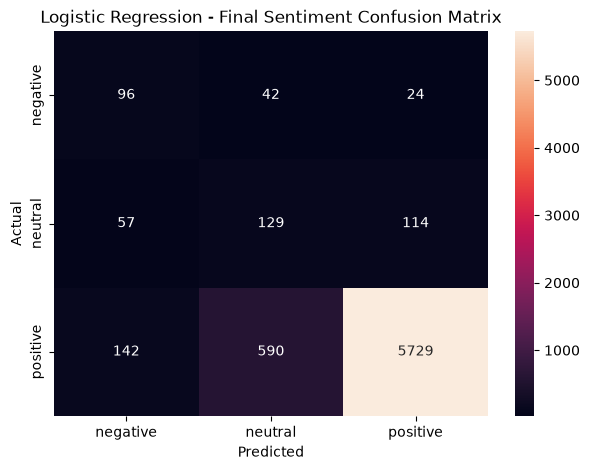

In [35]:
#Final confusion matrix
labels = ["negative", "neutral", "positive"]

cm = confusion_matrix(
    y_test,
    y_pred,
    labels=labels
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=labels,
    yticklabels=labels
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression - Final Sentiment Confusion Matrix")

plt.savefig(
    "../reports/figures/cm_final_model.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

## Step 8: save the final model

In [ ]:
import joblib
import sklearn

joblib.dump(
    pipe,
    "../models/sentiment_pipeline.pkl"
)

print("Model saved successfully.")
print("scikit-learn version:", sklearn.__version__)
print("Classes:", pipe.classes_)

Model saved successfully.
scikit-learn version: 1.9.0
Classes: ['negative' 'neutral' 'positive']
